
# DDXPlus Single-Agent Structured Policy Improvement

This notebook implements **Proposed Improvement 1** on top of the original sequential baseline.

What changes relative to the earlier single-agent notebook:

- a **deterministic evidence ledger / state manager** becomes the source of truth for the episode
- evidence is always shown in **decoded clinical language**, not token ids
- legal action handling keeps **parent-child gating** and explicit legality checks
- each turn uses **action shortlisting** instead of exposing the full remaining DDXPlus action space
- the agent can optionally see the **one-shot model's top-k prior differential** as advisory context
- the experiment is run across **multiple request budgets** rather than a single hard cap
- the notebook writes **budget-specific artifacts**, **paired one-shot comparisons**, and **visual analyses**

This is still a **single-agent** system. It is intentionally more structured and controlled than the baseline, but it does **not** yet implement more advanced algorithmic machinery such as probabilistic belief-state updating, graph inference, RL, or learned structured policies.


In [14]:

# Optional secure env bootstrap if you want to run live API calls from inside the notebook.
# Uncomment and run this cell before the main config cell if needed.

import os
from getpass import getpass

os.environ["LLM_BASE_URL"] = "https://api.openai.com/v1"
os.environ["LLM_MODEL"] = "gpt-4.1-mini"
if not os.environ.get("LLM_API_KEY"):
    os.environ["LLM_API_KEY"] = getpass("Enter LLM_API_KEY: ")


In [15]:

from __future__ import annotations

import ast
import json
import math
import os
import random
import re
import subprocess
import sys
import time
import zipfile
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 20)

ROOT = next(
    (
        candidate
        for candidate in [Path.cwd(), Path.cwd().parent]
        if (candidate / "scripts" / "download_ddxplus.py").exists()
    ),
    Path.cwd(),
)
DATASET_DIR = ROOT / ".data" / "ddxplus" / "22687585"
AUTO_DOWNLOAD_IF_MISSING = True

RUN_LIVE_API = True
ALLOW_DRY_RUN_BENCHMARK = False
RESUME_IF_AVAILABLE = True

REQUEST_BUDGETS = [1, 3, 5, 8]
SEQUENTIAL_SAMPLE_PER_CLASS = 1
SEQUENTIAL_MAX_CASES = 10
RANDOM_SEED = 2919
SPLIT_NAME = "test"
TEMPERATURE = 0.1

SHORTLIST_SIZE = 12
SHORTLIST_STATS_SOURCE = "validate"
SHORTLIST_STATS_MAX_ROWS = 30000
USE_ONE_SHOT_PRIOR = True
ONE_SHOT_PRIOR_TOP_K = 5
PRIOR_BLEND_WEIGHT = 0.35
STOP_CONFIDENCE_THRESHOLD = 0.60
STOP_STABILITY_TURNS = 2
LOW_VALUE_SHORTLIST_THRESHOLD = 0.18
MIN_REQUESTS_BEFORE_STRONG_STOP = 2

RUN_VERSION = "ledger_shortlist_budget_sweep_v1"

LLM_BASE_URL = os.environ.get("LLM_BASE_URL", "https://api.openai.com/v1")
LLM_API_KEY = os.environ.get("LLM_API_KEY", "")
LLM_MODEL = os.environ.get("LLM_MODEL", "gpt-5.4-mini")
USE_JSON_MODE = False  # keep False for provider compatibility unless your endpoint supports JSON mode cleanly

INPUT_COST_PER_1K_TOKENS = None
OUTPUT_COST_PER_1K_TOKENS = None

run_prefix = "live" if RUN_LIVE_API else "dryrun"
RUN_NAME = (
    f"single_agent_improved_{run_prefix}_{SPLIT_NAME}_"
    f"{SEQUENTIAL_SAMPLE_PER_CLASS}perclass_{len(REQUEST_BUDGETS)}budgets_{RUN_VERSION}"
)
ARTIFACT_ROOT = ROOT / "artifacts" / "sequential_single_agent_improved" / RUN_NAME
CACHE_DIR = ARTIFACT_ROOT / "cache"
FIGURE_DIR = ARTIFACT_ROOT / "figures"
for directory in [ARTIFACT_ROOT, CACHE_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root      :", ROOT)
print("Dataset dir       :", DATASET_DIR)
print("Run live API      :", RUN_LIVE_API)
print("Request budgets   :", REQUEST_BUDGETS)
print("Sample per class  :", SEQUENTIAL_SAMPLE_PER_CLASS)
print("Max benchmark rows:", SEQUENTIAL_MAX_CASES)
print("Artifact root     :", ARTIFACT_ROOT)


Project root      : /Users/bilalawan/claw/assignments/baseline_model
Dataset dir       : /Users/bilalawan/claw/assignments/baseline_model/.data/ddxplus/22687585
Run live API      : True
Request budgets   : [1, 3, 5, 8]
Sample per class  : 1
Max benchmark rows: 10
Artifact root     : /Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_single_agent_improved/single_agent_improved_live_test_1perclass_4budgets_ledger_shortlist_budget_sweep_v1



## Dataset And Artifact Helpers

The improved notebook keeps the same DDXPlus file-validation and split-loading conventions as the rest of the project so that:

- `case_id` remains stable
- one-shot predictions can be merged cleanly as priors
- sequential budget sweeps can be compared later without ad-hoc reformatting


In [16]:

REQUIRED_FILES = [
    "release_evidences.json",
    "release_conditions.json",
    "release_train_patients.zip",
    "release_validate_patients.zip",
    "release_test_patients.zip",
]

SPLIT_TO_FILENAME = {
    "train": "release_train_patients.zip",
    "validate": "release_validate_patients.zip",
    "test": "release_test_patients.zip",
}


def ensure_dataset_present(dataset_dir: Path, auto_download: bool = True) -> dict[str, Path]:
    dataset_dir.mkdir(parents=True, exist_ok=True)
    paths = {name: dataset_dir / name for name in REQUIRED_FILES}
    missing = [name for name, path in paths.items() if not path.exists()]
    if missing and auto_download:
        command = [sys.executable, str(ROOT / "scripts" / "download_ddxplus.py"), "--dataset-dir", str(dataset_dir)]
        subprocess.run(command, check=True)
        missing = [name for name, path in paths.items() if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Missing DDXPlus files: {missing}")
    return paths


def load_json(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def load_patient_split(zip_path: Path) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path, "r") as archive:
        members = [name for name in archive.namelist() if not name.endswith("/")]
        file_name = next((name for name in members if name.endswith(".csv")), None)
        if file_name is None:
            if not members:
                raise ValueError(f"Archive is empty: {zip_path}")
            file_name = members[0]
        with archive.open(file_name) as handle:
            return pd.read_csv(handle)


def attach_split_metadata(frame: pd.DataFrame, split_name: str) -> pd.DataFrame:
    enriched = frame.copy()
    enriched["split"] = split_name
    enriched["source_row_index"] = np.arange(len(enriched), dtype=int)
    enriched["case_id"] = enriched["source_row_index"].map(lambda idx: f"{split_name}:{idx}")
    return enriched


def sample_fixed_cases_per_pathology(frame: pd.DataFrame, label_col: str, per_class: int, seed: int) -> pd.DataFrame:
    sampled_parts = []
    for pathology, group in frame.groupby(label_col, sort=True):
        take_n = min(per_class, len(group))
        sampled_parts.append(group.sample(n=take_n, random_state=seed))
    sampled = pd.concat(sampled_parts, ignore_index=False)
    sampled = sampled.sort_values([label_col, "source_row_index"]).reset_index(drop=True)
    return sampled


def append_jsonl(path: Path, payload: dict[str, Any]) -> None:
    with path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(payload, ensure_ascii=True) + "\n")


def upsert_prediction_row(path: Path, row: dict[str, Any]) -> None:
    frame = pd.DataFrame([row])
    if path.exists():
        existing = pd.read_csv(path)
        existing = existing[existing["case_id"] != row["case_id"]]
        frame = pd.concat([existing, frame], ignore_index=True)
    frame.to_csv(path, index=False)


def safe_parse_list(raw: Any) -> list[Any]:
    if isinstance(raw, list):
        return raw
    if raw is None:
        return []
    if isinstance(raw, float) and np.isnan(raw):
        return []
    if isinstance(raw, str):
        stripped = raw.strip()
        if not stripped:
            return []
        try:
            return json.loads(stripped)
        except Exception:
            return ast.literal_eval(stripped)
    return list(raw)


## Deterministic Evidence Ledger And Episode State Manager

This notebook upgrades the episode representation so that the **ledger is the source of truth**.

Each episode state tracks:

- currently visible evidence
- requested evidence history
- decoded values and summaries
- current diagnosis snapshots
- shortlist history
- legality metadata for actions
- an optional one-shot prior differential

The LLM still makes the request/stop decision, but it does so against a much more explicit and controlled state representation.


In [17]:

def parse_evidence_token(token: str) -> tuple[str, str | None]:
    if "_@_" not in token:
        return token, None
    root_id, value = token.split("_@_", 1)
    return root_id, value


@dataclass
class LedgerEntry:
    turn_index: int
    root_evidence_id: str
    question_en: str
    source: str
    status: str
    values: list[str] = field(default_factory=list)
    decoded_values: list[str] = field(default_factory=list)
    summary: str = ""


@dataclass
class DiagnosisSnapshot:
    turn_index: int
    predicted_pathology: str
    ranked_differential: list[str]
    confidence: float
    decision: str
    requested_evidence_id: str | None
    brief_reasoning: str
    stop_signal_level: str
    top_shortlist_score: float


@dataclass
class LedgerEpisodeState:
    case_id: str
    split_name: str
    source_row_index: int
    age: int
    sex: str
    pathology: str
    initial_evidence: str
    evidence_by_root: dict[str, list[str]]
    revealed_roots: set[str]
    evidence_ledger: list[LedgerEntry]
    request_history: list[dict[str, Any]]
    diagnosis_history: list[DiagnosisSnapshot]
    shortlist_history: list[list[dict[str, Any]]]
    prior_differential: list[tuple[str, float]]


class DeterministicEvidenceLedger:
    def __init__(self, evidence_metadata: dict[str, dict[str, Any]]):
        self.evidence_metadata = evidence_metadata
        self.root_ids = list(evidence_metadata.keys())
        self.question_text = {
            root_id: meta.get("question_en", root_id) for root_id, meta in evidence_metadata.items()
        }
        self.data_types = {
            root_id: meta.get("data_type", "B") for root_id, meta in evidence_metadata.items()
        }
        self.parent_question = {
            root_id: str(meta.get("code_question", root_id) or root_id)
            for root_id, meta in evidence_metadata.items()
        }

    def tokens_to_values(self, root_id: str, tokens: list[str]) -> list[str]:
        if self.data_types[root_id] == "B":
            return ["present"] if tokens else []
        return [value for _, value in map(parse_evidence_token, tokens) if value is not None]

    def decode_value(self, root_id: str, value: str) -> str:
        if value == "present":
            return "yes"
        value_meaning = self.evidence_metadata[root_id].get("value_meaning", {})
        if isinstance(value_meaning, dict):
            entry = value_meaning.get(str(value))
            if isinstance(entry, dict):
                human = entry.get("en") or entry.get("fr")
                if human:
                    return str(human)
            elif entry:
                return str(entry)
        return str(value)

    def decode_values(self, root_id: str, values: list[str]) -> list[str]:
        return [self.decode_value(root_id, value) for value in values]

    def summarize_observation(self, root_id: str, values: list[str], status: str) -> str:
        question = self.question_text[root_id]
        if status == "absent":
            return f"{question} -> no"
        if self.data_types[root_id] == "B":
            return f"{question} -> yes"
        decoded_values = self.decode_values(root_id, values)
        return f"{question} -> {', '.join(decoded_values) if decoded_values else 'observed'}"

    def _make_entry(self, turn_index: int, root_id: str, source: str, status: str, values: list[str]) -> LedgerEntry:
        decoded_values = self.decode_values(root_id, values)
        return LedgerEntry(
            turn_index=turn_index,
            root_evidence_id=root_id,
            question_en=self.question_text[root_id],
            source=source,
            status=status,
            values=list(values),
            decoded_values=decoded_values,
            summary=self.summarize_observation(root_id, values, status),
        )

    def from_row(
        self,
        row: dict[str, Any],
        split_name: str,
        prior_differential: list[tuple[str, float]] | None = None,
    ) -> LedgerEpisodeState:
        evidences_list = [str(token) for token in safe_parse_list(row["EVIDENCES"])]
        initial_evidence = str(row["INITIAL_EVIDENCE"])
        initial_root, _ = parse_evidence_token(initial_evidence)
        evidence_by_root: dict[str, list[str]] = {}
        for token in evidences_list:
            root_id, _ = parse_evidence_token(token)
            evidence_by_root.setdefault(root_id, []).append(token)
        initial_values = self.tokens_to_values(initial_root, evidence_by_root.get(initial_root, [initial_evidence]))
        initial_entry = self._make_entry(0, initial_root, "initial_evidence", "present", initial_values)
        return LedgerEpisodeState(
            case_id=str(row["case_id"]),
            split_name=split_name,
            source_row_index=int(row["source_row_index"]),
            age=int(row["AGE"]),
            sex=str(row["SEX"]),
            pathology=str(row["PATHOLOGY"]),
            initial_evidence=initial_evidence,
            evidence_by_root=evidence_by_root,
            revealed_roots={initial_root},
            evidence_ledger=[initial_entry],
            request_history=[],
            diagnosis_history=[],
            shortlist_history=[],
            prior_differential=list(prior_differential or []),
        )

    def root_present_or_implied_present(self, root_id: str, episode: LedgerEpisodeState) -> bool:
        if root_id in episode.revealed_roots and bool(episode.evidence_by_root.get(root_id, [])):
            return True
        for revealed_root in episode.revealed_roots:
            if (
                self.parent_question.get(revealed_root, revealed_root) == root_id
                and bool(episode.evidence_by_root.get(revealed_root, []))
            ):
                return True
        return False

    def parent_is_satisfied(self, root_id: str, episode: LedgerEpisodeState) -> bool:
        parent_root = self.parent_question.get(root_id, root_id)
        if parent_root == root_id:
            return True
        return self.root_present_or_implied_present(parent_root, episode)

    def legal_actions(self, episode: LedgerEpisodeState) -> list[dict[str, Any]]:
        available = []
        for root_id in self.root_ids:
            if root_id in episode.revealed_roots:
                continue
            if not self.parent_is_satisfied(root_id, episode):
                continue
            parent_root = self.parent_question.get(root_id, root_id)
            available.append(
                {
                    "root_evidence_id": root_id,
                    "question_en": self.question_text[root_id],
                    "parent_root_id": parent_root,
                    "is_child": bool(parent_root != root_id),
                }
            )
        return available

    def reveal(self, episode: LedgerEpisodeState, root_evidence_id: str, turn_index: int) -> dict[str, Any]:
        episode.revealed_roots.add(root_evidence_id)
        revealed_tokens = list(episode.evidence_by_root.get(root_evidence_id, []))
        values = self.tokens_to_values(root_evidence_id, revealed_tokens)
        status = "present" if revealed_tokens else "absent"
        entry = self._make_entry(turn_index, root_evidence_id, "request", status, values)
        episode.evidence_ledger.append(entry)
        episode.request_history.append(
            {
                "turn_index": turn_index,
                "root_evidence_id": root_evidence_id,
                "status": status,
                "values": list(values),
                "decoded_values": list(entry.decoded_values),
                "summary": entry.summary,
            }
        )
        return {
            "root_evidence_id": root_evidence_id,
            "question_en": self.question_text[root_evidence_id],
            "status": status,
            "revealed_tokens": revealed_tokens,
            "revealed_values": list(values),
            "revealed_value_labels": list(entry.decoded_values),
            "summary": entry.summary,
        }

    def register_diagnosis(
        self,
        episode: LedgerEpisodeState,
        turn_index: int,
        normalized_response: dict[str, Any],
        shortlist_snapshot: list[dict[str, Any]],
        stop_signal: dict[str, Any],
    ) -> None:
        top_score = float(shortlist_snapshot[0]["score"]) if shortlist_snapshot else 0.0
        episode.diagnosis_history.append(
            DiagnosisSnapshot(
                turn_index=turn_index,
                predicted_pathology=normalized_response["predicted_pathology"],
                ranked_differential=list(normalized_response["ranked_differential"]),
                confidence=float(normalized_response["confidence"]),
                decision=str(normalized_response["decision"]),
                requested_evidence_id=normalized_response["requested_evidence_id"],
                brief_reasoning=str(normalized_response["brief_reasoning"]),
                stop_signal_level=str(stop_signal["level"]),
                top_shortlist_score=top_score,
            )
        )
        episode.shortlist_history.append(list(shortlist_snapshot))

    def render_ledger(self, episode: LedgerEpisodeState) -> str:
        return "\n".join(
            f"- {entry.root_evidence_id}: {entry.summary} [source={entry.source}]"
            for entry in episode.evidence_ledger
        )

    def request_history_text(self, episode: LedgerEpisodeState) -> str:
        if not episode.request_history:
            return "- no additional requests yet"
        return "\n".join(
            f"- turn {item['turn_index']}: {item['summary']}"
            for item in episode.request_history
        )

    def diagnosis_history_text(self, episode: LedgerEpisodeState) -> str:
        if not episode.diagnosis_history:
            return "- no diagnosis snapshots yet"
        return "\n".join(
            f"- turn {snap.turn_index}: pred={snap.predicted_pathology}, confidence={snap.confidence:.2f}, decision={snap.decision}"
            for snap in episode.diagnosis_history[-3:]
        )

    def visible_context(self, episode: LedgerEpisodeState) -> dict[str, Any]:
        return {
            "case_id": episode.case_id,
            "age": episode.age,
            "sex": episode.sex,
            "visible_ledger": self.render_ledger(episode),
            "request_history_text": self.request_history_text(episode),
            "diagnosis_history_text": self.diagnosis_history_text(episode),
        }


## One-Shot Priors, Deterministic Shortlisting, And Stop Guidance

The improvement direction here is **structured policy control**, not a learned policy.

The notebook therefore uses deterministic support signals:

- optional **one-shot priors** from the selected non-agentic baseline
- **pathology-evidence presence statistics** from DDXPlus
- a deterministic **shortlisting score** over legal actions each turn
- a deterministic **stop signal** that gives the agent a stronger hint about when another question is likely to be low value

This keeps the system single-agent and reproducible while still being meaningfully more controlled than the original baseline.


In [18]:

def discover_selected_one_shot_dir() -> Path | None:
    selected_path = ROOT / "artifacts" / "one_shot" / "selected_model.json"
    if not selected_path.exists():
        return None
    payload = load_json(selected_path)
    artifact_dir = payload.get("selected_artifact_dir")
    if not artifact_dir:
        return None
    return Path(artifact_dir)


def load_one_shot_prior_lookup(split_name: str, top_k: int) -> tuple[dict[str, list[tuple[str, float]]], pd.DataFrame | None]:
    one_shot_dir = discover_selected_one_shot_dir()
    if one_shot_dir is None:
        return {}, None
    predictions_path = one_shot_dir / "predictions.csv"
    if not predictions_path.exists():
        return {}, None
    frame = pd.read_csv(predictions_path)
    frame = frame[frame["split"] == split_name].copy()
    lookup = {}
    for row in frame.itertuples(index=False):
        preds = safe_parse_list(row.top5_predictions)
        scores = safe_parse_list(row.top5_prediction_scores)
        pairs = []
        for pathology, score in zip(preds[:top_k], scores[:top_k]):
            try:
                pairs.append((str(pathology), float(score)))
            except Exception:
                continue
        lookup[str(row.case_id)] = pairs
    return lookup, frame


def build_presence_rate_stats(
    frame: pd.DataFrame,
    evidence_metadata: dict[str, dict[str, Any]],
    source_name: str,
) -> dict[str, Any]:
    pathology_case_counts = Counter()
    pathology_root_counts: dict[str, Counter] = defaultdict(Counter)
    global_root_counts = Counter()
    all_roots = list(evidence_metadata.keys())
    for row in tqdm(frame[["PATHOLOGY", "EVIDENCES"]].itertuples(index=False), total=len(frame), desc=f"Presence stats ({source_name})"):
        pathology = str(row.PATHOLOGY)
        roots = {
            parse_evidence_token(str(token))[0]
            for token in safe_parse_list(row.EVIDENCES)
        }
        pathology_case_counts[pathology] += 1
        for root_id in roots:
            pathology_root_counts[pathology][root_id] += 1
            global_root_counts[root_id] += 1
    pathology_root_rates = {}
    for pathology, root_counter in pathology_root_counts.items():
        denom = max(1, pathology_case_counts[pathology])
        pathology_root_rates[pathology] = {
            root_id: float(root_counter.get(root_id, 0) / denom)
            for root_id in all_roots
        }
    global_root_rates = {
        root_id: float(global_root_counts.get(root_id, 0) / max(1, len(frame)))
        for root_id in all_roots
    }
    return {
        "source_name": source_name,
        "num_rows": int(len(frame)),
        "pathology_case_counts": dict(pathology_case_counts),
        "pathology_root_rates": pathology_root_rates,
        "global_root_rates": global_root_rates,
    }


def load_or_build_presence_rate_stats(
    dataset_paths: dict[str, Path],
    evidence_metadata: dict[str, dict[str, Any]],
    source_name: str,
    max_rows: int | None,
    seed: int,
) -> dict[str, Any]:
    cache_name = f"presence_rates_{source_name}_{max_rows or 'all'}.json"
    cache_path = CACHE_DIR / cache_name
    if cache_path.exists():
        return load_json(cache_path)
    if source_name not in SPLIT_TO_FILENAME:
        raise ValueError(f"Unsupported stats source: {source_name}")
    frame = attach_split_metadata(load_patient_split(dataset_paths[SPLIT_TO_FILENAME[source_name]]), source_name)
    if max_rows is not None and len(frame) > max_rows:
        frame = frame.sample(n=max_rows, random_state=seed).reset_index(drop=True)
    payload = build_presence_rate_stats(frame, evidence_metadata, source_name=source_name)
    with cache_path.open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2)
    return payload


@dataclass
class ShortlistAction:
    root_evidence_id: str
    question_en: str
    parent_root_id: str
    is_child: bool
    score: float
    weighted_present_rate: float
    weighted_std: float
    contrast: float
    global_present_rate: float
    reason: str


class DeterministicActionShortlister:
    def __init__(self, stats_payload: dict[str, Any], shortlist_size: int):
        self.pathology_root_rates = stats_payload["pathology_root_rates"]
        self.global_root_rates = stats_payload["global_root_rates"]
        self.shortlist_size = int(shortlist_size)

    def _descending_rank_weights(self, labels: list[str]) -> dict[str, float]:
        base = [1.0, 0.82, 0.67, 0.55, 0.45, 0.37, 0.30]
        return {label: base[min(idx, len(base) - 1)] for idx, label in enumerate(labels)}

    def candidate_pathology_weights(self, episode: LedgerEpisodeState) -> dict[str, float]:
        weights = Counter()
        if USE_ONE_SHOT_PRIOR and episode.prior_differential:
            for pathology, score in episode.prior_differential[:ONE_SHOT_PRIOR_TOP_K]:
                weights[pathology] += PRIOR_BLEND_WEIGHT * max(float(score), 1e-6)
        if episode.diagnosis_history:
            latest = episode.diagnosis_history[-1]
            latest_weights = self._descending_rank_weights(latest.ranked_differential)
            for pathology, score in latest_weights.items():
                weights[pathology] += score
        if not weights:
            fallback = [path for path, _ in episode.prior_differential[:ONE_SHOT_PRIOR_TOP_K]]
            fallback_weights = self._descending_rank_weights(fallback)
            if fallback_weights:
                weights.update(fallback_weights)
        total = float(sum(weights.values()))
        if total <= 0:
            return {}
        return {pathology: float(value / total) for pathology, value in weights.items()}

    def score_action(
        self,
        action: dict[str, Any],
        pathology_weights: dict[str, float],
    ) -> ShortlistAction:
        root_id = action["root_evidence_id"]
        if pathology_weights:
            labels = list(pathology_weights.keys())
            weights = np.array([pathology_weights[label] for label in labels], dtype=np.float32)
            rates = np.array(
                [self.pathology_root_rates.get(label, {}).get(root_id, self.global_root_rates.get(root_id, 0.0)) for label in labels],
                dtype=np.float32,
            )
        else:
            labels = []
            weights = np.array([1.0], dtype=np.float32)
            rates = np.array([self.global_root_rates.get(root_id, 0.0)], dtype=np.float32)
        weights = weights / max(weights.sum(), 1e-8)
        weighted_present_rate = float(np.dot(weights, rates))
        weighted_std = float(np.sqrt(np.dot(weights, (rates - weighted_present_rate) ** 2)))
        contrast = float(rates.max() - rates.min()) if len(rates) else 0.0
        global_present_rate = float(self.global_root_rates.get(root_id, 0.0))
        split_balance = 1.0 - abs(weighted_present_rate - 0.5) * 2.0
        global_balance = 1.0 - abs(global_present_rate - 0.5) * 2.0
        generic_penalty = 1.0
        question_lower = action["question_en"].lower()
        if "pain" in question_lower and global_present_rate > 0.35:
            generic_penalty *= 0.90
        if action["is_child"]:
            generic_penalty *= 0.97
        score = generic_penalty * (
            0.55 * weighted_std
            + 0.25 * contrast
            + 0.12 * split_balance
            + 0.08 * global_balance
        )
        reason = (
            f"contrast={contrast:.2f}, weighted_present={weighted_present_rate:.2f}, "
            f"global_present={global_present_rate:.2f}"
        )
        return ShortlistAction(
            root_evidence_id=root_id,
            question_en=action["question_en"],
            parent_root_id=action["parent_root_id"],
            is_child=bool(action["is_child"]),
            score=float(score),
            weighted_present_rate=weighted_present_rate,
            weighted_std=weighted_std,
            contrast=contrast,
            global_present_rate=global_present_rate,
            reason=reason,
        )

    def shortlist(
        self,
        episode: LedgerEpisodeState,
        legal_actions: list[dict[str, Any]],
    ) -> tuple[list[dict[str, Any]], dict[str, float]]:
        pathology_weights = self.candidate_pathology_weights(episode)
        scored = [self.score_action(action, pathology_weights) for action in legal_actions]
        scored.sort(key=lambda item: (-item.score, item.question_en))
        shortlist = [
            {
                "root_evidence_id": item.root_evidence_id,
                "question_en": item.question_en,
                "parent_root_id": item.parent_root_id,
                "is_child": item.is_child,
                "score": round(item.score, 4),
                "weighted_present_rate": round(item.weighted_present_rate, 4),
                "weighted_std": round(item.weighted_std, 4),
                "contrast": round(item.contrast, 4),
                "global_present_rate": round(item.global_present_rate, 4),
                "reason": item.reason,
            }
            for item in scored[: self.shortlist_size]
        ]
        return shortlist, pathology_weights


def consecutive_stable_prediction_turns(episode: LedgerEpisodeState) -> int:
    if not episode.diagnosis_history:
        return 0
    last_label = episode.diagnosis_history[-1].predicted_pathology
    stable = 0
    for snapshot in reversed(episode.diagnosis_history):
        if snapshot.predicted_pathology == last_label:
            stable += 1
        else:
            break
    return stable


def build_stop_signal(
    episode: LedgerEpisodeState,
    shortlist: list[dict[str, Any]],
    remaining_budget: int,
) -> dict[str, Any]:
    top_shortlist_score = float(shortlist[0]["score"]) if shortlist else 0.0
    stable_turns = consecutive_stable_prediction_turns(episode)
    last_snapshot = episode.diagnosis_history[-1] if episode.diagnosis_history else None
    if not shortlist:
        return {
            "level": "strong_stop",
            "reason": "No legal evidence requests remain.",
            "stable_turns": stable_turns,
            "top_shortlist_score": top_shortlist_score,
        }
    if (
        last_snapshot is not None
        and last_snapshot.confidence >= STOP_CONFIDENCE_THRESHOLD
        and stable_turns >= STOP_STABILITY_TURNS
        and top_shortlist_score < LOW_VALUE_SHORTLIST_THRESHOLD
        and len(episode.request_history) >= MIN_REQUESTS_BEFORE_STRONG_STOP
    ):
        return {
            "level": "strong_stop",
            "reason": "The leading diagnosis is stable, confidence is high, and the remaining shortlisted actions look low value.",
            "stable_turns": stable_turns,
            "top_shortlist_score": top_shortlist_score,
        }
    if (
        last_snapshot is not None
        and remaining_budget <= 1
        and last_snapshot.confidence >= 0.45
    ):
        return {
            "level": "moderate_stop",
            "reason": "The budget is nearly exhausted and the current diagnosis already has moderate confidence.",
            "stable_turns": stable_turns,
            "top_shortlist_score": top_shortlist_score,
        }
    if len(episode.request_history) >= 3 and top_shortlist_score < LOW_VALUE_SHORTLIST_THRESHOLD:
        return {
            "level": "moderate_stop",
            "reason": "The agent has already gathered multiple findings and the next shortlisted actions look weakly informative.",
            "stable_turns": stable_turns,
            "top_shortlist_score": top_shortlist_score,
        }
    return {
        "level": "continue",
        "reason": "There are still shortlisted actions with meaningful discriminative value.",
        "stable_turns": stable_turns,
        "top_shortlist_score": top_shortlist_score,
    }



## Prompt Contract And OpenAI-Compatible Adapter

The LLM remains a single agent, but the prompt is now more controlled:

- it sees the decoded evidence ledger
- it sees a deterministic shortlist rather than the full remaining action space
- it can optionally see the one-shot prior differential
- it also receives deterministic stop guidance derived from the ledger state

The agent still returns one strict JSON object per turn.


In [19]:

SEQUENTIAL_RESPONSE_SCHEMA = {
    "decision": "request | stop",
    "requested_evidence_id": "nullable shortlisted root evidence id",
    "predicted_pathology": "one of the 49 DDXPlus pathologies",
    "ranked_differential": "ordered list of up to 5 pathology names",
    "confidence": "float between 0 and 1",
    "brief_reasoning": "one short sentence",
}


def format_prior_text(episode: LedgerEpisodeState) -> str:
    if not episode.prior_differential:
        return "- no one-shot prior available"
    return "\n".join(
        f"- {pathology}: {score:.3f}"
        for pathology, score in episode.prior_differential[:ONE_SHOT_PRIOR_TOP_K]
    )


def format_candidate_weights(pathology_weights: dict[str, float]) -> str:
    if not pathology_weights:
        return "- no deterministic candidate weights available"
    pairs = sorted(pathology_weights.items(), key=lambda item: (-item[1], item[0]))[:5]
    return "\n".join(f"- {pathology}: {weight:.3f}" for pathology, weight in pairs)


def format_shortlist(shortlist: list[dict[str, Any]]) -> str:
    if not shortlist:
        return "- no legal actions remain"
    return "\n".join(
        (
            f"- {item['root_evidence_id']} | score={item['score']:.3f} | "
            f"present~{item['weighted_present_rate']:.2f} | {item['question_en']} | {item['reason']}"
        )
        for item in shortlist
    )


def build_system_prompt(label_names: list[str]) -> str:
    pathology_text = ", ".join(label_names)
    return (
        "You are a single diagnostic workup agent operating inside a structured DDXPlus environment. "
        "You must reason over the decoded evidence ledger, the deterministic shortlist, and the stop guidance. "
        "You may either request one additional evidence field from the shortlist or stop and finalize. "
        "The one-shot prior is only advisory context; it is not guaranteed to be correct. "
        "Never request evidence outside the shortlisted root ids. "
        "Always return exactly one JSON object and no extra text. "
        f"Valid pathology labels are: {pathology_text}."
    )


def build_user_prompt(
    ledger: DeterministicEvidenceLedger,
    episode: LedgerEpisodeState,
    shortlist: list[dict[str, Any]],
    pathology_weights: dict[str, float],
    stop_signal: dict[str, Any],
    turn_index: int,
    max_budget: int,
) -> str:
    remaining_budget = max_budget - turn_index + 1
    sections = [
        f"Case ID: {episode.case_id}",
        f"Turn: {turn_index}",
        f"Max request budget for this run: {max_budget}",
        f"Remaining request budget including this turn: {remaining_budget}",
        f"Demographics: age={episode.age}, sex={episode.sex}",
        "",
        "Decoded evidence ledger:",
        ledger.render_ledger(episode),
        "",
        "Requested evidence history:",
        ledger.request_history_text(episode),
        "",
        "Recent diagnosis history:",
        ledger.diagnosis_history_text(episode),
        "",
        "One-shot prior differential (initial evidence only):",
        format_prior_text(episode),
        "",
        "Deterministic candidate pathology weights for shortlisting:",
        format_candidate_weights(pathology_weights),
        "",
        "Stop guidance:",
        f"- level: {stop_signal['level']}",
        f"- rationale: {stop_signal['reason']}",
        f"- stable_prediction_turns: {stop_signal['stable_turns']}",
        f"- top_shortlist_score: {stop_signal['top_shortlist_score']:.3f}",
        "",
        "Shortlisted legal evidence requests for this turn:",
        format_shortlist(shortlist),
        "",
        "Return JSON with the following keys only:",
        json.dumps(SEQUENTIAL_RESPONSE_SCHEMA, indent=2),
        "",
        "Rules:",
        "- If decision is request, requested_evidence_id must be one of the shortlisted root ids shown above.",
        "- If decision is stop, requested_evidence_id must be null.",
        "- ranked_differential must contain at most 5 labels and predicted_pathology must appear in it.",
        "- Use the decoded ledger, request history, deterministic shortlist, and stop guidance together.",
        "- Avoid low-value generic requests when the stop guidance is moderate_stop or strong_stop.",
    ]
    return "\n".join(sections)


def build_messages(
    label_names: list[str],
    ledger: DeterministicEvidenceLedger,
    episode: LedgerEpisodeState,
    shortlist: list[dict[str, Any]],
    pathology_weights: dict[str, float],
    stop_signal: dict[str, Any],
    turn_index: int,
    max_budget: int,
) -> list[dict[str, str]]:
    return [
        {"role": "system", "content": build_system_prompt(label_names)},
        {
            "role": "user",
            "content": build_user_prompt(
                ledger=ledger,
                episode=episode,
                shortlist=shortlist,
                pathology_weights=pathology_weights,
                stop_signal=stop_signal,
                turn_index=turn_index,
                max_budget=max_budget,
            ),
        },
    ]


def chat_completion_url(base_url: str) -> str:
    cleaned = base_url.rstrip("/")
    if cleaned.endswith("/chat/completions"):
        return cleaned
    return f"{cleaned}/chat/completions"


def extract_content_text(response_payload: dict[str, Any]) -> str:
    message = response_payload["choices"][0]["message"]["content"]
    if isinstance(message, str):
        return message
    if isinstance(message, list):
        pieces = []
        for item in message:
            if isinstance(item, dict) and item.get("type") == "text":
                pieces.append(item.get("text", ""))
        return "".join(pieces)
    raise ValueError(f"Unsupported message content payload: {message!r}")


def call_openai_compatible(messages: list[dict[str, str]]) -> tuple[str, dict[str, Any], dict[str, int]]:
    if not LLM_API_KEY:
        raise ValueError("LLM_API_KEY is empty. Fill it via env vars or the secure notebook bootstrap cell.")
    body = {
        "model": LLM_MODEL,
        "messages": messages,
        "temperature": TEMPERATURE,
    }
    if USE_JSON_MODE:
        body["response_format"] = {"type": "json_object"}
    response = requests.post(
        chat_completion_url(LLM_BASE_URL),
        headers={
            "Authorization": f"Bearer {LLM_API_KEY}",
            "Content-Type": "application/json",
        },
        json=body,
        timeout=180,
    )
    response.raise_for_status()
    response_payload = response.json()
    usage = response_payload.get("usage", {})
    token_usage = {
        "input_tokens": int(usage.get("prompt_tokens", 0) or 0),
        "output_tokens": int(usage.get("completion_tokens", 0) or 0),
    }
    return extract_content_text(response_payload), response_payload, token_usage


def parse_json_response(raw_text: str) -> dict[str, Any]:
    cleaned = raw_text.strip()
    match = re.search(r"\{.*\}", cleaned, flags=re.S)
    if not match:
        raise ValueError("No JSON object found in the model response.")
    return json.loads(match.group(0))


def _coerce_ranked_list(value: Any) -> list[str]:
    if value is None:
        return []
    if isinstance(value, list):
        return [str(item).strip() for item in value if str(item).strip()]
    if isinstance(value, str):
        stripped = value.strip()
        if not stripped:
            return []
        try:
            parsed = json.loads(stripped)
            if isinstance(parsed, list):
                return [str(item).strip() for item in parsed if str(item).strip()]
        except Exception:
            try:
                parsed = ast.literal_eval(stripped)
                if isinstance(parsed, list):
                    return [str(item).strip() for item in parsed if str(item).strip()]
            except Exception:
                pass
        return [item.strip() for item in stripped.split("|") if item.strip()]
    return []


def normalize_agent_response(payload: dict[str, Any], label_names: list[str]) -> dict[str, Any]:
    decision = str(payload.get("decision", "stop")).strip().lower()
    if decision not in {"request", "stop"}:
        decision = "stop"
    requested_evidence_id = payload.get("requested_evidence_id")
    if requested_evidence_id in ("", "null", "None"):
        requested_evidence_id = None
    if requested_evidence_id is not None:
        requested_evidence_id = str(requested_evidence_id).strip()
    predicted_pathology = str(payload.get("predicted_pathology", "")).strip()
    ranked_differential = _coerce_ranked_list(payload.get("ranked_differential"))
    valid_ranked = []
    for item in ranked_differential:
        if item in label_names and item not in valid_ranked:
            valid_ranked.append(item)
    if predicted_pathology in label_names and predicted_pathology not in valid_ranked:
        valid_ranked.insert(0, predicted_pathology)
    if not predicted_pathology and valid_ranked:
        predicted_pathology = valid_ranked[0]
    try:
        confidence = float(payload.get("confidence", 0.0) or 0.0)
    except Exception:
        confidence = 0.0
    confidence = float(np.clip(confidence, 0.0, 1.0))
    brief_reasoning = str(payload.get("brief_reasoning", "")).strip()[:400]
    return {
        "decision": decision,
        "requested_evidence_id": requested_evidence_id if decision == "request" else None,
        "predicted_pathology": predicted_pathology,
        "ranked_differential": valid_ranked[:5],
        "confidence": confidence,
        "brief_reasoning": brief_reasoning,
    }


def validate_agent_response(
    normalized_response: dict[str, Any],
    shortlist_ids: set[str],
    label_names: list[str],
) -> str | None:
    if normalized_response["predicted_pathology"] not in label_names:
        return "predicted_pathology is missing or outside the DDXPlus label set."
    if not normalized_response["ranked_differential"]:
        return "ranked_differential is empty."
    if normalized_response["decision"] == "request":
        requested = normalized_response["requested_evidence_id"]
        if requested is None:
            return "decision=request but requested_evidence_id is null."
        if requested not in shortlist_ids:
            return "requested_evidence_id is not in the current shortlist."
    return None


def build_repair_messages(
    messages: list[dict[str, str]],
    raw_text: str,
    error_message: str,
) -> list[dict[str, str]]:
    return [
        *messages,
        {"role": "assistant", "content": raw_text},
        {
            "role": "user",
            "content": (
                "Your previous response violated the required JSON contract. "
                f"Problem: {error_message}. "
                "Return one corrected JSON object only."
            ),
        },
    ]


def scripted_dry_run_response(
    episode: LedgerEpisodeState,
    shortlist: list[dict[str, Any]],
    pathology_weights: dict[str, float],
    stop_signal: dict[str, Any],
    turn_index: int,
    max_budget: int,
    label_names: list[str],
) -> dict[str, Any]:
    candidate_labels = list(pathology_weights.keys()) or [path for path, _ in episode.prior_differential]
    if not candidate_labels:
        candidate_labels = list(label_names[:5])
    ranked = candidate_labels[:5]
    predicted = ranked[0]
    confidence = 0.35 + 0.08 * min(3, len(episode.request_history))
    if stop_signal["level"] == "strong_stop":
        return {
            "decision": "stop",
            "requested_evidence_id": None,
            "predicted_pathology": predicted,
            "ranked_differential": ranked,
            "confidence": min(0.85, confidence + 0.15),
            "brief_reasoning": "Dry-run mode stops because the deterministic stop signal is strong.",
        }
    if turn_index >= min(max_budget, 3) or not shortlist:
        return {
            "decision": "stop",
            "requested_evidence_id": None,
            "predicted_pathology": predicted,
            "ranked_differential": ranked,
            "confidence": min(0.75, confidence),
            "brief_reasoning": "Dry-run mode stops after a small number of scripted requests.",
        }
    top_action = shortlist[0]
    return {
        "decision": "request",
        "requested_evidence_id": top_action["root_evidence_id"],
        "predicted_pathology": predicted,
        "ranked_differential": ranked,
        "confidence": min(0.70, confidence),
        "brief_reasoning": "Dry-run mode requests the highest-scoring shortlisted action.",
    }


def get_agent_response_with_repair(
    label_names: list[str],
    ledger: DeterministicEvidenceLedger,
    episode: LedgerEpisodeState,
    shortlist: list[dict[str, Any]],
    pathology_weights: dict[str, float],
    stop_signal: dict[str, Any],
    turn_index: int,
    max_budget: int,
) -> dict[str, Any]:
    messages = build_messages(
        label_names=label_names,
        ledger=ledger,
        episode=episode,
        shortlist=shortlist,
        pathology_weights=pathology_weights,
        stop_signal=stop_signal,
        turn_index=turn_index,
        max_budget=max_budget,
    )
    shortlist_ids = {item["root_evidence_id"] for item in shortlist}
    raw_attempts = []
    api_calls = 0
    input_tokens = 0
    output_tokens = 0
    estimated_cost = None

    if not RUN_LIVE_API:
        raw_text = json.dumps(
            scripted_dry_run_response(
                episode=episode,
                shortlist=shortlist,
                pathology_weights=pathology_weights,
                stop_signal=stop_signal,
                turn_index=turn_index,
                max_budget=max_budget,
                label_names=label_names,
            )
        )
        payload = {"dry_run": True, "message": raw_text}
        token_usage = {"input_tokens": 0, "output_tokens": 0}
        api_calls = 1
    else:
        raw_text, payload, token_usage = call_openai_compatible(messages)
        api_calls = 1
    raw_attempts.append({"attempt_index": 1, "raw_text": raw_text, "payload": payload})
    input_tokens += token_usage["input_tokens"]
    output_tokens += token_usage["output_tokens"]

    try:
        normalized = normalize_agent_response(parse_json_response(raw_text), label_names)
        error_message = validate_agent_response(normalized, shortlist_ids, label_names)
    except Exception as exc:
        normalized = None
        error_message = str(exc)

    if error_message is not None:
        repair_messages = build_repair_messages(messages, raw_text, error_message)
        if not RUN_LIVE_API:
            repair_text = json.dumps(
                scripted_dry_run_response(
                    episode=episode,
                    shortlist=shortlist,
                    pathology_weights=pathology_weights,
                    stop_signal={**stop_signal, "level": "strong_stop"},
                    turn_index=turn_index,
                    max_budget=max_budget,
                    label_names=label_names,
                )
            )
            repair_payload = {"dry_run": True, "message": repair_text}
            repair_usage = {"input_tokens": 0, "output_tokens": 0}
            api_calls += 1
        else:
            repair_text, repair_payload, repair_usage = call_openai_compatible(repair_messages)
            api_calls += 1
        raw_attempts.append({"attempt_index": 2, "raw_text": repair_text, "payload": repair_payload})
        input_tokens += repair_usage["input_tokens"]
        output_tokens += repair_usage["output_tokens"]
        normalized = normalize_agent_response(parse_json_response(repair_text), label_names)
        error_message = validate_agent_response(normalized, shortlist_ids, label_names)

    error_flags = []
    if error_message is not None:
        error_flags.append(error_message)
        fallback_labels = list(pathology_weights.keys()) or [path for path, _ in episode.prior_differential]
        fallback_labels = [label for label in fallback_labels if label in label_names][:5]
        if not fallback_labels:
            fallback_labels = [label_names[0]]
        normalized = {
            "decision": "stop",
            "requested_evidence_id": None,
            "predicted_pathology": fallback_labels[0],
            "ranked_differential": fallback_labels,
            "confidence": 0.0,
            "brief_reasoning": "Forced stop after invalid responses.",
        }

    return {
        "messages": messages,
        "normalized_response": normalized,
        "raw_attempts": raw_attempts,
        "api_calls": api_calls,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "estimated_cost": estimated_cost,
        "error_flags": error_flags,
    }


## Prepare Benchmark Cases, Load Priors, And Build Shortlisting Statistics

This section:

- loads the DDXPlus split used for sequential evaluation
- fixes a deterministic benchmark subset
- loads one-shot priors when available
- builds or reuses cached evidence-presence statistics for deterministic shortlisting


In [20]:

dataset_paths = ensure_dataset_present(DATASET_DIR, auto_download=AUTO_DOWNLOAD_IF_MISSING)
evidences = load_json(dataset_paths["release_evidences.json"])
conditions = load_json(dataset_paths["release_conditions.json"])
label_names = list(conditions.keys())

raw_split = attach_split_metadata(load_patient_split(dataset_paths[SPLIT_TO_FILENAME[SPLIT_NAME]]), SPLIT_NAME)
benchmark_df = sample_fixed_cases_per_pathology(
    raw_split,
    label_col="PATHOLOGY",
    per_class=SEQUENTIAL_SAMPLE_PER_CLASS,
    seed=RANDOM_SEED,
)
if SEQUENTIAL_MAX_CASES is not None:
    benchmark_df = (
        benchmark_df.sample(n=min(SEQUENTIAL_MAX_CASES, len(benchmark_df)), random_state=RANDOM_SEED)
        .sort_values(["PATHOLOGY", "source_row_index"])
        .reset_index(drop=True)
    )

prior_lookup, one_shot_prediction_frame = load_one_shot_prior_lookup(SPLIT_NAME, ONE_SHOT_PRIOR_TOP_K)
benchmark_df["prior_available"] = benchmark_df["case_id"].map(lambda case_id: case_id in prior_lookup)

presence_stats = load_or_build_presence_rate_stats(
    dataset_paths=dataset_paths,
    evidence_metadata=evidences,
    source_name=SHORTLIST_STATS_SOURCE,
    max_rows=SHORTLIST_STATS_MAX_ROWS,
    seed=RANDOM_SEED,
)

ledger = DeterministicEvidenceLedger(evidences)
shortlister = DeterministicActionShortlister(presence_stats, shortlist_size=SHORTLIST_SIZE)

benchmark_df[["case_id", "PATHOLOGY", "AGE", "SEX", "INITIAL_EVIDENCE", "prior_available"]].to_csv(
    ARTIFACT_ROOT / "benchmark_cases.csv",
    index=False,
)

print("Benchmark size           :", len(benchmark_df))
print("Unique pathologies       :", benchmark_df["PATHOLOGY"].nunique())
print("One-shot prior coverage  :", int(benchmark_df["prior_available"].sum()), "/", len(benchmark_df))
print("Shortlist stats source   :", presence_stats["source_name"], "rows=", presence_stats["num_rows"])
display(benchmark_df[["case_id", "PATHOLOGY", "AGE", "SEX", "INITIAL_EVIDENCE", "prior_available"]].head(10))


Presence stats (validate):   0%|          | 0/30000 [00:00<?, ?it/s]

Benchmark size           : 10
Unique pathologies       : 10
One-shot prior coverage  : 10 / 10
Shortlist stats source   : validate rows= 30000


,case_id,PATHOLOGY,AGE,SEX,INITIAL_EVIDENCE,prior_available
0,test:104857,Acute dystonic reactions,18,M,E_172,True
1,test:51421,Chagas,7,M,E_91,True
2,test:81691,Croup,9,F,E_181,True
3,test:77908,Ebola,35,F,E_51,True
4,test:34242,Guillain-Barré syndrome,16,M,E_84,True
5,test:95923,Pneumonia,24,F,E_66,True
6,test:23687,Pulmonary embolism,31,F,E_220,True
7,test:16097,Stable angina,51,F,E_66,True
8,test:107472,Tuberculosis,64,M,E_91,True
9,test:19424,Whooping cough,62,M,E_166,True



## Preview A Structured Turn

The preview below shows the new prompt ingredients before any live evaluation:

- decoded ledger
- one-shot prior
- deterministic candidate weights
- stop guidance
- shortlisted actions with scores and reasons


In [21]:

preview_row = benchmark_df.iloc[0].to_dict()
preview_episode = ledger.from_row(
    preview_row,
    split_name=SPLIT_NAME,
    prior_differential=prior_lookup.get(preview_row["case_id"], []),
)
preview_legal_actions = ledger.legal_actions(preview_episode)
preview_shortlist, preview_candidate_weights = shortlister.shortlist(preview_episode, preview_legal_actions)
preview_stop_signal = build_stop_signal(preview_episode, preview_shortlist, remaining_budget=max(REQUEST_BUDGETS))
preview_messages = build_messages(
    label_names=label_names,
    ledger=ledger,
    episode=preview_episode,
    shortlist=preview_shortlist,
    pathology_weights=preview_candidate_weights,
    stop_signal=preview_stop_signal,
    turn_index=1,
    max_budget=max(REQUEST_BUDGETS),
)
preview_response = scripted_dry_run_response(
    episode=preview_episode,
    shortlist=preview_shortlist,
    pathology_weights=preview_candidate_weights,
    stop_signal=preview_stop_signal,
    turn_index=1,
    max_budget=max(REQUEST_BUDGETS),
    label_names=label_names,
)

print("=== SYSTEM MESSAGE ===")
print(preview_messages[0]["content"][:1500] + "...")
print("\n=== USER MESSAGE (truncated) ===")
print(preview_messages[1]["content"][:3500] + "...")
print("\n=== SCHEMA-VALID PREVIEW RESPONSE ===")
print(json.dumps(preview_response, indent=2))

=== SYSTEM MESSAGE ===
You are a single diagnostic workup agent operating inside a structured DDXPlus environment. You must reason over the decoded evidence ledger, the deterministic shortlist, and the stop guidance. You may either request one additional evidence field from the shortlist or stop and finalize. The one-shot prior is only advisory context; it is not guaranteed to be correct. Never request evidence outside the shortlisted root ids. Always return exactly one JSON object and no extra text. Valid pathology labels are: Spontaneous pneumothorax, Cluster headache, Boerhaave, Spontaneous rib fracture, GERD, HIV (initial infection), Anemia, Viral pharyngitis, Inguinal hernia, Myasthenia gravis, Whooping cough, Anaphylaxis, Epiglottitis, Guillain-Barré syndrome, Acute laryngitis, Croup, PSVT, Atrial fibrillation, Bronchiectasis, Allergic sinusitis, Chagas, Scombroid food poisoning, Myocarditis, Larygospasm, Acute dystonic reactions, Localized edema, SLE, Tuberculosis, Unstable angi


## Budget Sweep Execution And Artifact Writing

The same benchmark cases are evaluated under multiple request budgets. Each budget gets its own artifact directory with:

- `predictions.csv`
- `traces.jsonl`
- `raw_api_responses.jsonl`
- `metrics.json`
- `paired_vs_one_shot.csv`
- `comparison_summary.json`

The notebook also writes a root-level `budget_sweep_summary.csv` so later notebooks or reports can analyze the tradeoff between request budget, efficiency, and performance.


In [22]:


def top_k_accuracy_from_lists(true_labels: list[str], ranked_lists: list[list[str]], k: int) -> float:
    hits = []
    for true_label, ranked in zip(true_labels, ranked_lists):
        hits.append(true_label in list(ranked)[:k])
    return float(np.mean(hits)) if hits else 0.0


def compute_sequential_metrics(prediction_frame: pd.DataFrame) -> dict[str, Any]:
    ranked_lists = prediction_frame["ranked_differential"].map(safe_parse_list).tolist()
    true_labels = prediction_frame["true_pathology"].astype(str).tolist()
    pred_labels = prediction_frame["predicted_pathology"].astype(str).tolist()
    metrics = {
        "accuracy": float(np.mean(prediction_frame["correct"])) if len(prediction_frame) else 0.0,
        "top3_accuracy": top_k_accuracy_from_lists(true_labels, ranked_lists, 3),
        "top5_accuracy": top_k_accuracy_from_lists(true_labels, ranked_lists, 5),
        "macro_f1": float(f1_score(true_labels, pred_labels, average="macro")) if len(prediction_frame) else 0.0,
        "mean_requests": float(prediction_frame["num_requests"].mean()) if len(prediction_frame) else 0.0,
        "stop_before_cap_rate": float(np.mean(prediction_frame["stop_reason"] == "agent_stop")) if len(prediction_frame) else 0.0,
        "mean_api_calls": float(prediction_frame["api_calls"].mean()) if len(prediction_frame) else 0.0,
        "total_input_tokens": int(prediction_frame["input_tokens"].fillna(0).sum()) if len(prediction_frame) else 0,
        "total_output_tokens": int(prediction_frame["output_tokens"].fillna(0).sum()) if len(prediction_frame) else 0,
        "total_estimated_cost": (
            float(prediction_frame["estimated_cost"].fillna(0).sum())
            if prediction_frame["estimated_cost"].notna().any()
            else None
        ),
        "turn_distribution": {
            str(key): int(value) for key, value in prediction_frame["num_requests"].value_counts().sort_index().items()
        },
    }
    return metrics


def compute_one_shot_paired_metrics(paired_frame: pd.DataFrame) -> dict[str, Any]:
    top5_lists = paired_frame["top5_predictions_one_shot"].map(safe_parse_list).tolist()
    true_labels = paired_frame["true_pathology"].astype(str).tolist()
    pred_labels = paired_frame["pred_pathology_one_shot"].astype(str).tolist()
    return {
        "accuracy": float(np.mean(paired_frame["correct_one_shot"])),
        "top3_accuracy": top_k_accuracy_from_lists(true_labels, top5_lists, 3),
        "top5_accuracy": top_k_accuracy_from_lists(true_labels, top5_lists, 5),
        "macro_f1": float(f1_score(true_labels, pred_labels, average="macro")),
    }


def paired_win_loss(paired_frame: pd.DataFrame) -> dict[str, int]:
    both_correct = int(np.sum(paired_frame["correct_seq"] & paired_frame["correct_one_shot"]))
    seq_only = int(np.sum(paired_frame["correct_seq"] & ~paired_frame["correct_one_shot"]))
    one_only = int(np.sum(~paired_frame["correct_seq"] & paired_frame["correct_one_shot"]))
    both_wrong = int(np.sum(~paired_frame["correct_seq"] & ~paired_frame["correct_one_shot"]))
    return {
        "both_correct": both_correct,
        "sequential_only_correct": seq_only,
        "one_shot_only_correct": one_only,
        "both_wrong": both_wrong,
    }


def run_budget_sweep() -> pd.DataFrame:
    summary_rows = []
    resolved_run_config = {
        "run_name": RUN_NAME,
        "run_live_api": RUN_LIVE_API,
        "allow_dry_run_benchmark": ALLOW_DRY_RUN_BENCHMARK,
        "resume_if_available": RESUME_IF_AVAILABLE,
        "request_budgets": list(REQUEST_BUDGETS),
        "split_name": SPLIT_NAME,
        "random_seed": RANDOM_SEED,
        "sequential_sample_per_class": SEQUENTIAL_SAMPLE_PER_CLASS,
        "sequential_max_cases": SEQUENTIAL_MAX_CASES,
        "shortlist_size": SHORTLIST_SIZE,
        "shortlist_stats_source": SHORTLIST_STATS_SOURCE,
        "shortlist_stats_max_rows": SHORTLIST_STATS_MAX_ROWS,
        "use_one_shot_prior": USE_ONE_SHOT_PRIOR,
        "one_shot_prior_top_k": ONE_SHOT_PRIOR_TOP_K,
        "llm_base_url": LLM_BASE_URL,
        "llm_model": LLM_MODEL,
    }
    with (ARTIFACT_ROOT / "resolved_run_config.json").open("w", encoding="utf-8") as handle:
        json.dump(resolved_run_config, handle, indent=2)

    if not RUN_LIVE_API and not ALLOW_DRY_RUN_BENCHMARK:
        print("Budget sweep skipped. Enable RUN_LIVE_API or ALLOW_DRY_RUN_BENCHMARK.")
        return pd.DataFrame()

    for budget in REQUEST_BUDGETS:
        budget_dir = ARTIFACT_ROOT / f"budget_{budget:03d}"
        budget_dir.mkdir(parents=True, exist_ok=True)
        predictions_path = budget_dir / "predictions.csv"
        traces_path = budget_dir / "traces.jsonl"
        raw_api_path = budget_dir / "raw_api_responses.jsonl"

        processed_case_ids = set()
        if RESUME_IF_AVAILABLE and predictions_path.exists():
            processed_case_ids = set(pd.read_csv(predictions_path)["case_id"].astype(str).tolist())
            print(f"Budget {budget}: resuming with {len(processed_case_ids)} completed cases.")

        if RUN_LIVE_API and not LLM_API_KEY:
            raise ValueError("RUN_LIVE_API=True but LLM_API_KEY is empty.")

        started_at = time.time()
        for row in tqdm(list(benchmark_df.to_dict(orient="records")), desc=f"Budget {budget}"):
            case_id = str(row["case_id"])
            if case_id in processed_case_ids:
                continue
            episode = ledger.from_row(
                row,
                split_name=SPLIT_NAME,
                prior_differential=prior_lookup.get(case_id, []),
            )
            case_trace = []
            total_api_calls = 0
            total_input_tokens = 0
            total_output_tokens = 0
            total_estimated_cost = 0.0
            has_cost = False
            error_flags = []
            final_response = None
            stop_reason = "max_requests_reached"

            for turn_index in range(1, budget + 1):
                legal_actions = ledger.legal_actions(episode)
                shortlist, pathology_weights = shortlister.shortlist(episode, legal_actions)
                stop_signal = build_stop_signal(episode, shortlist, remaining_budget=budget - turn_index + 1)
                turn_bundle = get_agent_response_with_repair(
                    label_names=label_names,
                    ledger=ledger,
                    episode=episode,
                    shortlist=shortlist,
                    pathology_weights=pathology_weights,
                    stop_signal=stop_signal,
                    turn_index=turn_index,
                    max_budget=budget,
                )
                normalized = turn_bundle["normalized_response"]
                final_response = normalized
                total_api_calls += turn_bundle["api_calls"]
                total_input_tokens += turn_bundle["input_tokens"]
                total_output_tokens += turn_bundle["output_tokens"]
                if turn_bundle["estimated_cost"] is not None:
                    total_estimated_cost += float(turn_bundle["estimated_cost"])
                    has_cost = True
                error_flags.extend(turn_bundle["error_flags"])

                ledger.register_diagnosis(
                    episode=episode,
                    turn_index=turn_index,
                    normalized_response=normalized,
                    shortlist_snapshot=shortlist,
                    stop_signal=stop_signal,
                )

                for raw_attempt in turn_bundle["raw_attempts"]:
                    append_jsonl(
                        raw_api_path,
                        {
                            "case_id": case_id,
                            "budget": budget,
                            "turn_index": turn_index,
                            **raw_attempt,
                        },
                    )

                trace_step = {
                    "turn_index": turn_index,
                    "visible_context_before": ledger.visible_context(episode),
                    "shortlist": shortlist,
                    "deterministic_candidate_weights": pathology_weights,
                    "stop_signal": stop_signal,
                    "agent_response": normalized,
                    "error_flags": list(turn_bundle["error_flags"]),
                }

                if normalized["decision"] == "request" and turn_index <= budget and shortlist:
                    reveal_payload = ledger.reveal(episode, normalized["requested_evidence_id"], turn_index)
                    trace_step["reveal_payload"] = reveal_payload
                    stop_reason = "max_requests_reached" if turn_index == budget else "requested_more_evidence"
                    case_trace.append(trace_step)
                    if turn_index == budget:
                        break
                    continue

                stop_reason = "agent_stop"
                case_trace.append(trace_step)
                break

            prediction_row = {
                "case_id": episode.case_id,
                "budget": budget,
                "source_row_index": episode.source_row_index,
                "split": episode.split_name,
                "AGE": episode.age,
                "SEX": episode.sex,
                "true_pathology": episode.pathology,
                "predicted_pathology": final_response["predicted_pathology"],
                "correct": bool(final_response["predicted_pathology"] == episode.pathology),
                "ranked_differential": json.dumps(final_response["ranked_differential"]),
                "final_confidence": float(final_response["confidence"]),
                "num_requests": sum(1 for step in case_trace if step["agent_response"]["decision"] == "request"),
                "stop_reason": stop_reason,
                "api_calls": total_api_calls,
                "input_tokens": total_input_tokens,
                "output_tokens": total_output_tokens,
                "estimated_cost": (total_estimated_cost if has_cost else np.nan),
                "initial_evidence": episode.initial_evidence,
                "prior_top1": (episode.prior_differential[0][0] if episode.prior_differential else None),
                "prior_top1_score": (episode.prior_differential[0][1] if episode.prior_differential else np.nan),
                "error_flags": json.dumps(error_flags),
            }
            upsert_prediction_row(predictions_path, prediction_row)
            append_jsonl(
                traces_path,
                {
                    "case_id": episode.case_id,
                    "budget": budget,
                    "true_pathology": episode.pathology,
                    "predicted_pathology": final_response["predicted_pathology"],
                    "stop_reason": stop_reason,
                    "num_requests": prediction_row["num_requests"],
                    "trace": case_trace,
                },
            )

        prediction_frame = pd.read_csv(predictions_path)
        metrics_payload = {
            "run_name": RUN_NAME,
            "budget": budget,
            "num_cases": int(len(prediction_frame)),
            "runtime_seconds": float(time.time() - started_at),
            "metrics": compute_sequential_metrics(prediction_frame),
            "notes": (
                "Dry-run budget sweep results are for pipeline validation only."
                if not RUN_LIVE_API
                else "Live API-backed improved single-agent sequential baseline."
            ),
        }
        with (budget_dir / "metrics.json").open("w", encoding="utf-8") as handle:
            json.dump(metrics_payload, handle, indent=2)

        summary_row = {
            "budget": budget,
            "num_cases": int(len(prediction_frame)),
            "runtime_seconds": metrics_payload["runtime_seconds"],
            **metrics_payload["metrics"],
        }

        if one_shot_prediction_frame is not None:
            one_shot_columns = [
                "case_id",
                "pred_pathology",
                "correct",
                "top5_predictions",
                "top1_confidence",
            ]
            paired = prediction_frame.merge(
                one_shot_prediction_frame[one_shot_columns],
                on="case_id",
                how="left",
                suffixes=("_seq", "_one_shot"),
            )
            paired = paired.rename(
                columns={
                    "correct": "correct_seq",
                    "pred_pathology": "pred_pathology_one_shot",
                    "top5_predictions": "top5_predictions_one_shot",
                    "top1_confidence": "top1_confidence_one_shot",
                    "correct_one_shot": "correct_one_shot",
                }
            )
            if "correct_one_shot" not in paired.columns and "correct" in paired.columns:
                paired = paired.rename(columns={"correct": "correct_one_shot"})
            paired.to_csv(budget_dir / "paired_vs_one_shot.csv", index=False)
            comparison_payload = {
                "budget": budget,
                "num_paired_cases": int(len(paired)),
                "sequential": compute_sequential_metrics(prediction_frame),
                "one_shot": compute_one_shot_paired_metrics(paired),
                "win_loss": paired_win_loss(paired),
            }
            with (budget_dir / "comparison_summary.json").open("w", encoding="utf-8") as handle:
                json.dump(comparison_payload, handle, indent=2)
            summary_row.update(
                {
                    "one_shot_accuracy_same_cases": comparison_payload["one_shot"]["accuracy"],
                    "one_shot_top3_same_cases": comparison_payload["one_shot"]["top3_accuracy"],
                    "one_shot_top5_same_cases": comparison_payload["one_shot"]["top5_accuracy"],
                    "seq_only_wins": comparison_payload["win_loss"]["sequential_only_correct"],
                    "one_shot_only_wins": comparison_payload["win_loss"]["one_shot_only_correct"],
                    "both_correct": comparison_payload["win_loss"]["both_correct"],
                    "both_wrong": comparison_payload["win_loss"]["both_wrong"],
                }
            )

        summary_rows.append(summary_row)

    summary_frame = pd.DataFrame(summary_rows).sort_values("budget").reset_index(drop=True)
    summary_frame.to_csv(ARTIFACT_ROOT / "budget_sweep_summary.csv", index=False)
    return summary_frame


summary_frame = run_budget_sweep()
display(summary_frame)


Budget 1:   0%|          | 0/10 [00:00<?, ?it/s]

Budget 3:   0%|          | 0/10 [00:00<?, ?it/s]

Budget 5:   0%|          | 0/10 [00:00<?, ?it/s]

Budget 8:   0%|          | 0/10 [00:00<?, ?it/s]

,budget,num_cases,runtime_seconds,accuracy,top3_accuracy,top5_accuracy,macro_f1,mean_requests,stop_before_cap_rate,mean_api_calls,...,total_output_tokens,total_estimated_cost,turn_distribution,one_shot_accuracy_same_cases,one_shot_top3_same_cases,one_shot_top5_same_cases,seq_only_wins,one_shot_only_wins,both_correct,both_wrong
0,1,10,33.597645,0.3,0.4,0.4,0.1875,1.0,0.0,1.0,...,1182,None,{'1': 10},0.3,0.4,0.4,0,0,3,7
1,3,10,80.463181,0.2,0.4,0.4,0.1250,2.7,0.3,3.0,...,3557,None,"{'2': 3, '3': 7}",0.3,0.4,0.4,0,1,2,7
2,5,10,151.049353,0.1,0.4,0.4,0.0625,4.4,0.6,5.0,...,5921,None,"{'4': 6, '5': 4}",0.3,0.4,0.4,0,2,1,7
3,8,10,232.797744,0.2,0.4,0.4,0.1250,7.0,0.9,7.9,...,9403,None,"{'6': 1, '7': 8, '8': 1}",0.3,0.4,0.4,1,2,1,6



## Visual Analysis Across Request Budgets

These plots make the tradeoff between request budget, efficiency, stopping behavior, and diagnostic performance easier to inspect.


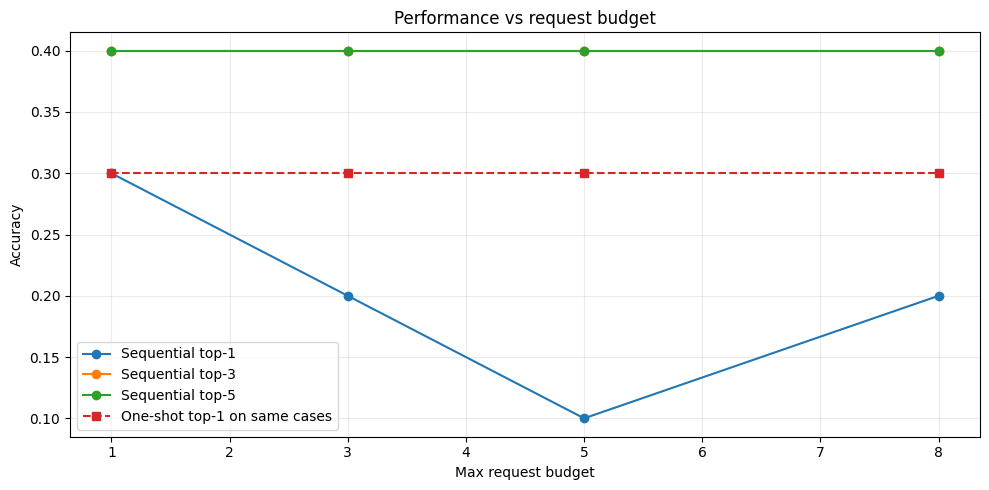

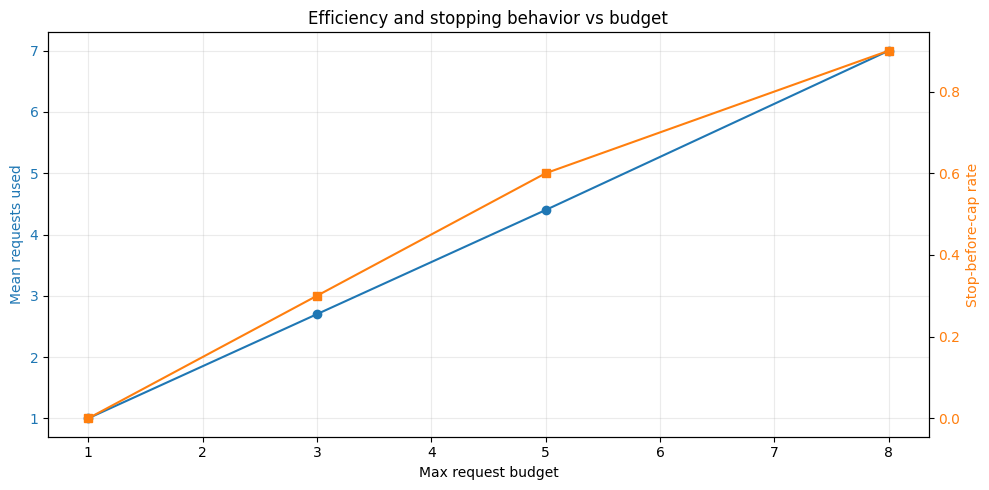

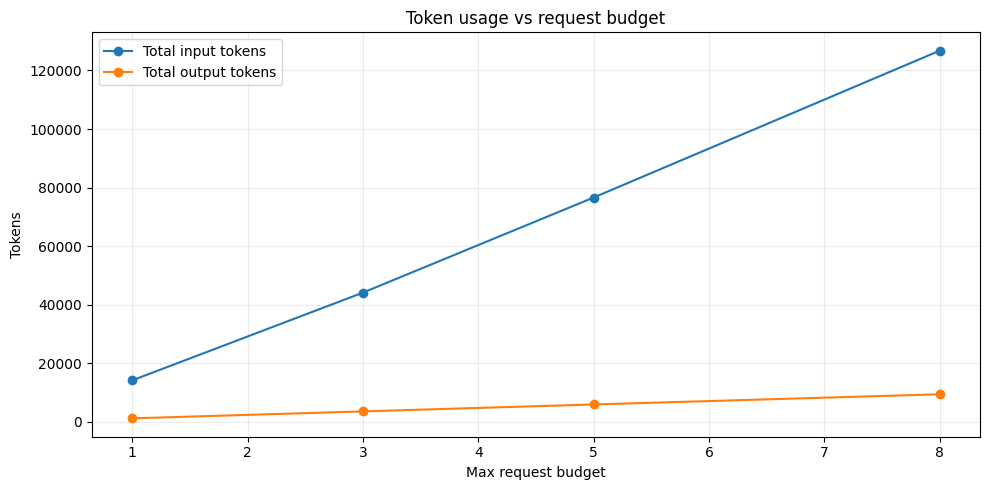

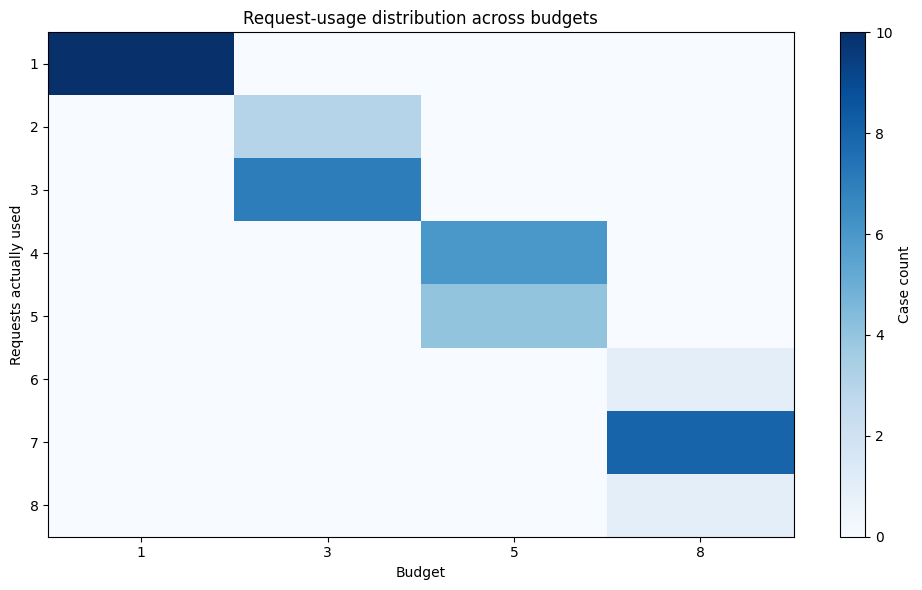

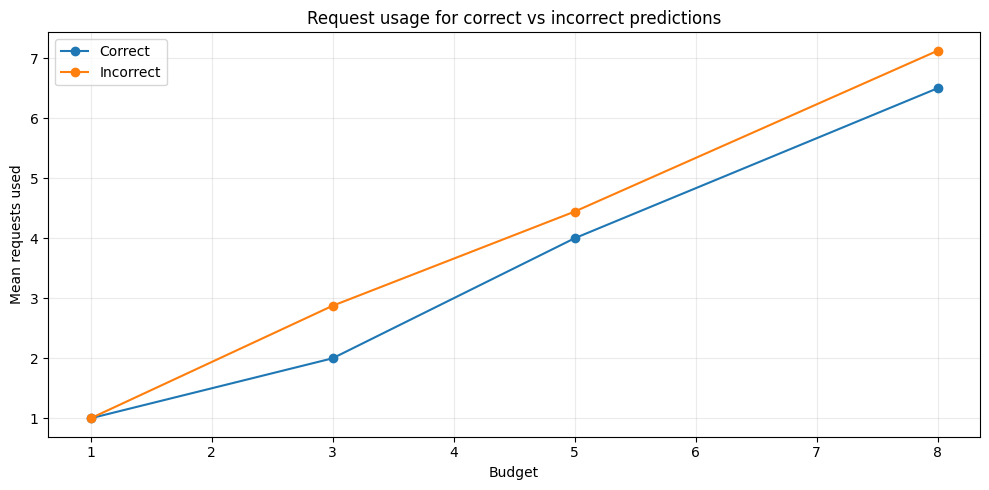

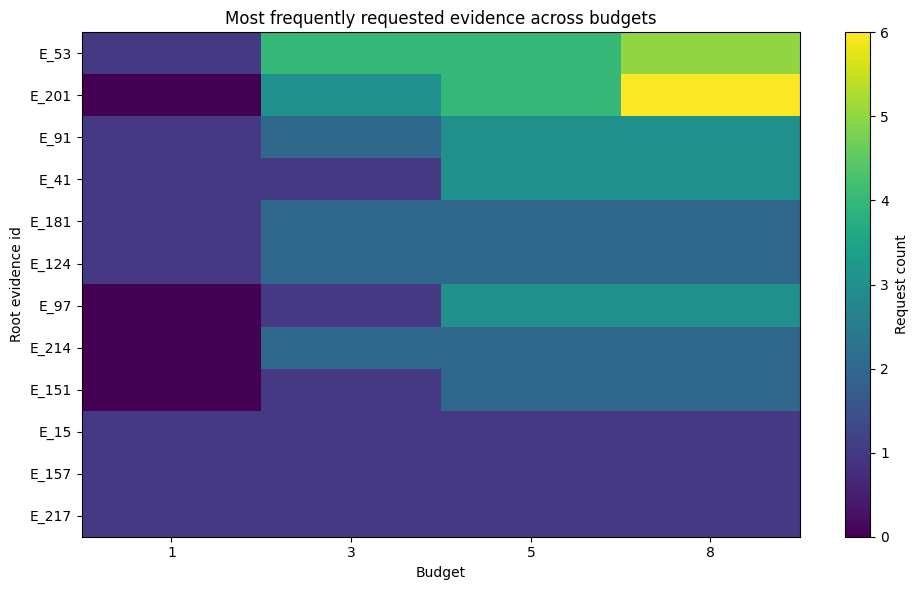

,budget,num_cases,runtime_seconds,accuracy,top3_accuracy,top5_accuracy,macro_f1,mean_requests,stop_before_cap_rate,mean_api_calls,...,total_output_tokens,total_estimated_cost,turn_distribution,one_shot_accuracy_same_cases,one_shot_top3_same_cases,one_shot_top5_same_cases,seq_only_wins,one_shot_only_wins,both_correct,both_wrong
0,1,10,33.597645,0.3,0.4,0.4,0.1875,1.0,0.0,1.0,...,1182,NaN,{'1': 10},0.3,0.4,0.4,0,0,3,7
1,3,10,80.463181,0.2,0.4,0.4,0.1250,2.7,0.3,3.0,...,3557,NaN,"{'2': 3, '3': 7}",0.3,0.4,0.4,0,1,2,7
2,5,10,151.049353,0.1,0.4,0.4,0.0625,4.4,0.6,5.0,...,5921,NaN,"{'4': 6, '5': 4}",0.3,0.4,0.4,0,2,1,7
3,8,10,232.797744,0.2,0.4,0.4,0.1250,7.0,0.9,7.9,...,9403,NaN,"{'6': 1, '7': 8, '8': 1}",0.3,0.4,0.4,1,2,1,6


In [23]:

summary_path = ARTIFACT_ROOT / "budget_sweep_summary.csv"
if not summary_path.exists():
    raise FileNotFoundError("No budget_sweep_summary.csv found. Run the budget sweep cell first.")
summary_frame = pd.read_csv(summary_path)

all_predictions = []
request_counter_by_budget = defaultdict(Counter)
for budget in REQUEST_BUDGETS:
    budget_dir = ARTIFACT_ROOT / f"budget_{budget:03d}"
    pred_path = budget_dir / "predictions.csv"
    trace_path = budget_dir / "traces.jsonl"
    if pred_path.exists():
        pred_frame = pd.read_csv(pred_path)
        pred_frame["budget"] = budget
        all_predictions.append(pred_frame)
    if trace_path.exists():
        with trace_path.open("r", encoding="utf-8") as handle:
            for line in handle:
                row = json.loads(line)
                for step in row.get("trace", []):
                    requested = step.get("agent_response", {}).get("requested_evidence_id")
                    if requested:
                        request_counter_by_budget[budget][requested] += 1
all_predictions = pd.concat(all_predictions, ignore_index=True) if all_predictions else pd.DataFrame()

plt.figure(figsize=(10, 5))
plt.plot(summary_frame["budget"], summary_frame["accuracy"], marker="o", label="Sequential top-1")
plt.plot(summary_frame["budget"], summary_frame["top3_accuracy"], marker="o", label="Sequential top-3")
plt.plot(summary_frame["budget"], summary_frame["top5_accuracy"], marker="o", label="Sequential top-5")
if "one_shot_accuracy_same_cases" in summary_frame.columns:
    plt.plot(summary_frame["budget"], summary_frame["one_shot_accuracy_same_cases"], linestyle="--", marker="s", label="One-shot top-1 on same cases")
plt.xlabel("Max request budget")
plt.ylabel("Accuracy")
plt.title("Performance vs request budget")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "performance_vs_budget.png", dpi=180)
plt.show()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(summary_frame["budget"], summary_frame["mean_requests"], marker="o", color="tab:blue", label="Mean requests used")
ax1.set_xlabel("Max request budget")
ax1.set_ylabel("Mean requests used", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(alpha=0.25)
ax2 = ax1.twinx()
ax2.plot(summary_frame["budget"], summary_frame["stop_before_cap_rate"], marker="s", color="tab:orange", label="Stop-before-cap rate")
ax2.set_ylabel("Stop-before-cap rate", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
plt.title("Efficiency and stopping behavior vs budget")
fig.tight_layout()
plt.savefig(FIGURE_DIR / "efficiency_and_stopping_vs_budget.png", dpi=180)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(summary_frame["budget"], summary_frame["total_input_tokens"], marker="o", label="Total input tokens")
plt.plot(summary_frame["budget"], summary_frame["total_output_tokens"], marker="o", label="Total output tokens")
plt.xlabel("Max request budget")
plt.ylabel("Tokens")
plt.title("Token usage vs request budget")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "token_usage_vs_budget.png", dpi=180)
plt.show()

if not all_predictions.empty:
    pivot = all_predictions.pivot_table(
        index="num_requests",
        columns="budget",
        values="case_id",
        aggfunc="count",
        fill_value=0,
    )
    plt.figure(figsize=(10, 6))
    plt.imshow(pivot.values, aspect="auto", cmap="Blues")
    plt.colorbar(label="Case count")
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.xlabel("Budget")
    plt.ylabel("Requests actually used")
    plt.title("Request-usage distribution across budgets")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "request_usage_heatmap.png", dpi=180)
    plt.show()

    plt.figure(figsize=(10, 5))
    correct_means = all_predictions.groupby(["budget", "correct"])["num_requests"].mean().unstack(fill_value=0)
    for is_correct, label in [(True, "Correct"), (False, "Incorrect")]:
        if is_correct in correct_means.columns:
            plt.plot(correct_means.index, correct_means[is_correct], marker="o", label=label)
    plt.xlabel("Budget")
    plt.ylabel("Mean requests used")
    plt.title("Request usage for correct vs incorrect predictions")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "requests_correct_vs_incorrect.png", dpi=180)
    plt.show()

if request_counter_by_budget:
    all_roots = Counter()
    for counter in request_counter_by_budget.values():
        all_roots.update(counter)
    top_roots = [root for root, _ in all_roots.most_common(12)]
    heatmap = np.zeros((len(top_roots), len(REQUEST_BUDGETS)), dtype=int)
    for col, budget in enumerate(REQUEST_BUDGETS):
        for row, root_id in enumerate(top_roots):
            heatmap[row, col] = request_counter_by_budget[budget].get(root_id, 0)
    plt.figure(figsize=(10, 6))
    plt.imshow(heatmap, aspect="auto", cmap="viridis")
    plt.colorbar(label="Request count")
    plt.yticks(range(len(top_roots)), top_roots)
    plt.xticks(range(len(REQUEST_BUDGETS)), REQUEST_BUDGETS)
    plt.xlabel("Budget")
    plt.ylabel("Root evidence id")
    plt.title("Most frequently requested evidence across budgets")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "top_requested_evidence_heatmap.png", dpi=180)
    plt.show()

display(summary_frame)



## Qualitative Trace Snapshots

The cell below extracts a few interpretable examples from the highest-accuracy budget so the run is not only summarized numerically.


In [24]:

if summary_frame.empty:
    print("No summary rows available.")
else:
    best_budget = int(summary_frame.sort_values(["accuracy", "top3_accuracy", "budget"], ascending=[False, False, True]).iloc[0]["budget"])
    best_budget_dir = ARTIFACT_ROOT / f"budget_{best_budget:03d}"
    paired_path = best_budget_dir / "paired_vs_one_shot.csv"
    trace_path = best_budget_dir / "traces.jsonl"

    trace_lookup = {}
    if trace_path.exists():
        with trace_path.open("r", encoding="utf-8") as handle:
            for line in handle:
                row = json.loads(line)
                trace_lookup[row["case_id"]] = row

    qualitative_examples = []
    if paired_path.exists():
        paired = pd.read_csv(paired_path)
        candidate_groups = [
            (paired[(paired["correct_seq"]) & (~paired["correct_one_shot"])], "sequential_only_win"),
            (paired[(~paired["correct_seq"]) & (paired["correct_one_shot"])], "one_shot_only_win"),
            (paired[(paired["correct_seq"]) & (paired["correct_one_shot"])], "both_correct"),
        ]
        for group_frame, label in candidate_groups:
            if len(group_frame) == 0:
                continue
            row = group_frame.iloc[0]
            trace_row = trace_lookup.get(str(row["case_id"]))
            qualitative_examples.append(
                {
                    "label": label,
                    "case_id": str(row["case_id"]),
                    "true_pathology": str(row["true_pathology"]),
                    "sequential_prediction": str(row["predicted_pathology"]),
                    "one_shot_prediction": str(row.get("pred_pathology_one_shot", "")),
                    "num_requests": int(row["num_requests"]),
                    "stop_reason": str(row["stop_reason"]),
                    "trace": trace_row,
                }
            )
    with (ARTIFACT_ROOT / "qualitative_examples_best_budget.json").open("w", encoding="utf-8") as handle:
        json.dump(qualitative_examples, handle, indent=2)

    print("Best budget:", best_budget)
    print("Saved qualitative examples to:", ARTIFACT_ROOT / "qualitative_examples_best_budget.json")
    display(pd.DataFrame([{k: v for k, v in item.items() if k != "trace"} for item in qualitative_examples]))


Best budget: 1
Saved qualitative examples to: /Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_single_agent_improved/single_agent_improved_live_test_1perclass_4budgets_ledger_shortlist_budget_sweep_v1/qualitative_examples_best_budget.json


,label,case_id,true_pathology,sequential_prediction,one_shot_prediction,num_requests,stop_reason
0,both_correct,test:104857,Acute dystonic reactions,Acute dystonic reactions,Acute dystonic reactions,1,max_requests_reached
